In [25]:
import sys

# Install required packages using the current Python interpreter
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install opencv-contrib-python
!{sys.executable} -m pip install numpy pandas pillow matplotlib

In [26]:
# ==========================================
# CELL 2 : IMPORT LIBRARIES
# ==========================================

import cv2
import os
import numpy as np
import pandas as pd
from PIL import Image
from datetime import datetime
import matplotlib.pyplot as plt
import csv
import time



In [27]:


print("=" * 60)
print(" SMART ATTENDANCE SYSTEM USING FACE RECOGNITION ")
print("=" * 60)

print("OpenCV Version :", cv2.__version__)
print("NumPy Version  :", np.__version__)
print("Pandas Version :", pd.__version__)

print("\n✅ All libraries imported successfully!")

 SMART ATTENDANCE SYSTEM USING FACE RECOGNITION 
OpenCV Version : 5.0.0
NumPy Version  : 2.5.1
Pandas Version : 3.0.3

✅ All libraries imported successfully!


In [28]:
import os

DATASET_PATH = "dataset/dataset/Dataset/Faces/"

if os.path.exists(DATASET_PATH):
    print("✅ Dataset Found")
    print("Number of persons:", len(os.listdir(DATASET_PATH)))
    print("First 10 folders:")
    print(os.listdir(DATASET_PATH)[:10])
else:
    print("❌ Path is still incorrect.")

✅ Dataset Found
Number of persons: 2
First 10 folders:
['Akshay Kumar', 'Jhansi']


In [29]:
# ==========================================
# CELL 4 : TRAIN FACE RECOGNIZER
# ==========================================

import cv2
import os
import numpy as np
from PIL import Image
import pickle

dataset_path = "dataset/dataset/Dataset/Faces"
cascade_path = "haarcascade_frontalface_default.xml"

detector = cv2.CascadeClassifier(cascade_path)

faces = []
ids = []
names = {}

current_id = 0

for person in sorted(os.listdir(dataset_path)):
    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    names[current_id] = person

    print(f"Processing: {person}")

    for image_name in os.listdir(person_path):

        image_path = os.path.join(person_path, image_name)

        try:
            img = Image.open(image_path).convert("L")
        except:
            print(f"Cannot read: {image_name}")
            continue

        img_np = np.array(img, "uint8")

        detected_faces = detector.detectMultiScale(
            img_np,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(50, 50)
        )

        if len(detected_faces) == 0:
            print(f"No face detected: {image_name}")

        for (x, y, w, h) in detected_faces:
            faces.append(img_np[y:y+h, x:x+w])
            ids.append(current_id)

    current_id += 1

if len(faces) == 0:
    print("❌ No faces detected in the dataset.")
else:
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.train(faces, np.array(ids))
    recognizer.save("trainer.yml")

    with open("names.pkl", "wb") as f:
        pickle.dump(names, f)

    print("=" * 50)
    print("✅ Training Completed Successfully")
    print("Total Persons :", len(names))
    print("Total Faces :", len(faces))
    print("Model Saved : trainer.yml")
    print("Names Saved : names.pkl")
    print("=" * 50)

Processing: Akshay Kumar
No face detected: Akshay Kumar_7.jpg
Processing: Jhansi
✅ Training Completed Successfully
Total Persons : 2
Total Faces : 20
Model Saved : trainer.yml
Names Saved : names.pkl


In [30]:
import os
import pandas as pd

# Delete old attendance file if it exists
if os.path.exists("attendance.csv"):
    os.remove("attendance.csv")

# Create new attendance file
df = pd.DataFrame(columns=["Name", "Date", "Time"])
df.to_csv("attendance.csv", index=False)

print("✅ attendance.csv created")

✅ attendance.csv created


In [31]:
import pandas as pd

df = pd.read_csv("attendance.csv")
print(df.columns)

Index(['Name', 'Date', 'Time'], dtype='str')


In [32]:
import cv2

face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

camera = cv2.VideoCapture(0)

while True:

    ret, frame = camera.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60,60)
    )

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(frame, "Face Detected", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    cv2.imshow("Face Detection Test", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

camera.release()
cv2.destroyAllWindows()

In [33]:
# ==========================================
# CELL 5A : FACE RECOGNITION TEST
# ==========================================

import cv2
import pickle

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

# Load trained model
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("trainer.yml")

# Load names
with open("names.pkl", "rb") as f:
    names = pickle.load(f)

# Open Camera
camera = cv2.VideoCapture(0)

if not camera.isOpened():
    print("❌ Camera could not be opened")
else:
    print("✅ Camera Started")
    print("Press 'q' inside the camera window to exit")

while camera.isOpened():

    ret, frame = camera.read()

    if not ret:
        print("❌ Failed to capture frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60,60)
    )

    for (x, y, w, h) in faces:

        face = gray[y:y+h, x:x+w]

        label, confidence = recognizer.predict(face)

        print(f"Label: {label}  Confidence: {confidence:.2f}")
        if confidence < 90:

            person = names.get(label, "Unknown")

            mark_attendance(person)

            text = f"{person} ({confidence:.1f})"

            color = (0,255,0)

       
        else:

            text = "Unknown"

            color = (0,0,255)

        cv2.rectangle(frame,(x,y),(x+w,y+h),color,2)

        cv2.putText(
            frame,
            text,
            (x,y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            color,
            2
        )

    cv2.imshow("Face Recognition", frame)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'):
        break

camera.release()
cv2.destroyAllWindows()

print("✅ Camera Closed")

✅ Camera Started
Press 'q' inside the camera window to exit
Label: 1  Confidence: 62.63
✅ Attendance Marked: Jhansi
Label: 1  Confidence: 63.41
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 63.14
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 63.22
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 60.87
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 63.55
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 63.74
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 62.98
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 62.87
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 62.62
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 63.03
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 63.01
ℹ️ Attendance already marked today for Jhansi
Label: 1  Confidence: 60.44
ℹ️ Attendance already marked today for Jha

In [34]:
# ==========================================
# CELL 5B : ATTENDANCE MARKING
# ==========================================

import pandas as pd
import os
from datetime import datetime

attendance_file = "attendance.csv"

# Create attendance file if it doesn't exist
if not os.path.exists(attendance_file):
    df = pd.DataFrame(columns=["Name", "Date", "Time"])
    df.to_csv(attendance_file, index=False)

# Call this function inside Cell 5A when a face is recognized
def mark_attendance(person):

    now = datetime.now()
    date = now.strftime("%d-%m-%Y")
    time = now.strftime("%H:%M:%S")

    df = pd.read_csv(attendance_file)

    # Check if attendance is already marked today
    already_marked = (
        (df["Name"] == person) &
        (df["Date"] == date)
    ).any()

    if not already_marked:

        new_row = pd.DataFrame({
            "Name": [person],
            "Date": [date],
            "Time": [time]
        })

        df = pd.concat([df, new_row], ignore_index=True)
        df.to_csv(attendance_file, index=False)

        print(f"✅ Attendance Marked: {person}")

    else:
        print(f"ℹ️ Attendance already marked today for {person}")

In [35]:
mark_attendance("Jhansi")

ℹ️ Attendance already marked today for Jhansi


SMART ATTENDANCE ANALYTICS

Attendance Records:

     Name        Date      Time
0  Jhansi  31-07-2026  17:54:28

Total Attendance Records : 1

Attendance Count Per Student

Name
Jhansi    1
Name: count, dtype: int64


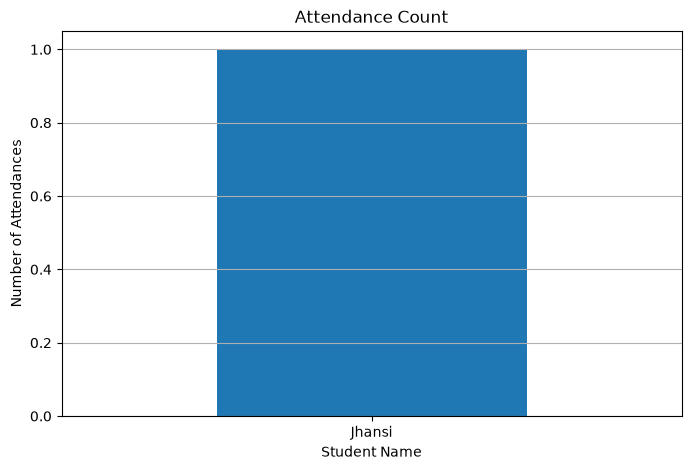

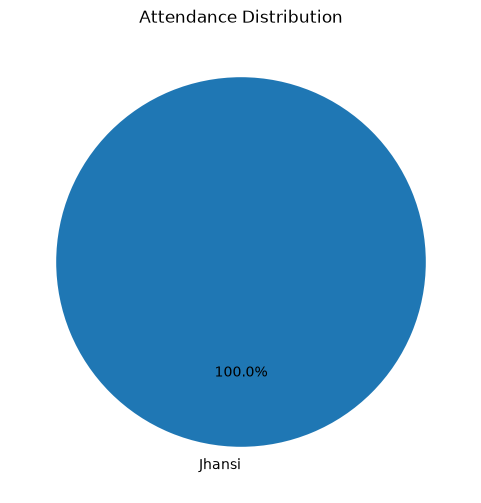

In [36]:
# ==========================================
# CELL 6 : ATTENDANCE ANALYTICS DASHBOARD
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

try:
    # Read attendance file
    df = pd.read_csv("attendance.csv")

    if df.empty:
        print("❌ No attendance records found.")

    else:

        print("=" * 60)
        print("SMART ATTENDANCE ANALYTICS")
        print("=" * 60)

        print("\nAttendance Records:\n")
        print(df)

        print("\nTotal Attendance Records :", len(df))

        # Attendance count per student
        attendance_count = df["Name"].value_counts()

        print("\nAttendance Count Per Student\n")
        print(attendance_count)

        # ------------------------
        # Bar Chart
        # ------------------------
        plt.figure(figsize=(8,5))
        attendance_count.plot(kind="bar")
        plt.title("Attendance Count")
        plt.xlabel("Student Name")
        plt.ylabel("Number of Attendances")
        plt.xticks(rotation=0)
        plt.grid(axis="y")
        plt.show()

        # ------------------------
        # Pie Chart
        # ------------------------
        plt.figure(figsize=(6,6))
        attendance_count.plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title("Attendance Distribution")
        plt.ylabel("")
        plt.show()

except FileNotFoundError:
    print("❌ attendance.csv file not found.")

except Exception as e:
    print("Error :", e)

In [39]:
# ==========================================
# CELL 7 : SEARCH ATTENDANCE
# ==========================================

import pandas as pd

df = pd.read_csv("attendance.csv")

print("="*50)
print("SEARCH ATTENDANCE RECORD")
print("="*50)

name = input("Enter Student Name: ")

result = df[df["Name"].str.lower() == name.lower()]

if len(result) > 0:
    print("\nAttendance Found\n")
    print(result)
else:
    print("\nNo Attendance Record Found")

SEARCH ATTENDANCE RECORD


Enter Student Name:  Jhansi



Attendance Found

     Name        Date      Time
0  Jhansi  31-07-2026  17:54:28


In [40]:
import sys
!{sys.executable} -m pip install openpyxl

In [41]:
# ==========================================
# CELL 8 : EXPORT TO EXCEL
# ==========================================

import pandas as pd

df = pd.read_csv("attendance.csv")

df.to_excel("attendance_report.xlsx", index=False)

print("===================================")
print("Attendance Exported Successfully")
print("File Name : attendance_report.xlsx")
print("===================================")

Attendance Exported Successfully
File Name : attendance_report.xlsx


In [42]:
# ==========================================
# CELL 10 : VIEW TODAY'S ATTENDANCE
# ==========================================

import pandas as pd
from datetime import datetime

today = datetime.now().strftime("%d-%m-%Y")

df = pd.read_csv("attendance.csv")

today_attendance = df[df["Date"] == today]

print("=" * 50)
print("TODAY'S ATTENDANCE")
print("=" * 50)

if today_attendance.empty:
    print("No attendance marked today.")
else:
    print(today_attendance)
    print("\nTotal Students Present:", len(today_attendance))

TODAY'S ATTENDANCE
     Name        Date      Time
0  Jhansi  31-07-2026  17:54:28

Total Students Present: 1


In [43]:
# ==========================================
# CELL 11 : ATTENDANCE PERCENTAGE
# ==========================================

import pandas as pd

df = pd.read_csv("attendance.csv")

total_days = df["Date"].nunique()

attendance = df["Name"].value_counts()

print("=" * 50)
print("ATTENDANCE PERCENTAGE")
print("=" * 50)

for student, present in attendance.items():
    percentage = (present / total_days) * 100
    print(f"{student} : {percentage:.2f}%")

ATTENDANCE PERCENTAGE
Jhansi : 100.00%


In [44]:
# ==========================================
# CELL 12 : PROJECT COMPLETED
# ==========================================

print("=" * 60)
print("SMART ATTENDANCE SYSTEM USING FACE RECOGNITION")
print("=" * 60)

print("""
Project Features

✅ Dataset Creation
✅ Face Detection (Haar Cascade)
✅ Face Recognition (LBPH)
✅ Model Training
✅ Real-Time Face Recognition
✅ Automatic Attendance
✅ Duplicate Attendance Prevention
✅ Attendance Analytics
✅ Search Attendance
✅ Export to Excel
✅ Today's Attendance
✅ Attendance Percentage

Project Status : SUCCESSFULLY COMPLETED

Thank You
""")

SMART ATTENDANCE SYSTEM USING FACE RECOGNITION

Project Features

✅ Dataset Creation
✅ Face Detection (Haar Cascade)
✅ Face Recognition (LBPH)
✅ Model Training
✅ Real-Time Face Recognition
✅ Automatic Attendance
✅ Duplicate Attendance Prevention
✅ Attendance Analytics
✅ Search Attendance
✅ Export to Excel
✅ Today's Attendance
✅ Attendance Percentage

Project Status : SUCCESSFULLY COMPLETED

Thank You

